import dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.feature_extraction.text import TfidfVectorizer


Load Dataset

In [2]:
df = pd.read_csv("C:/Users/user/OneDrive/Documents/Learn AI/Deep Learning/Sentiment_Analysis/sentiment_data.csv")

check dataset

In [3]:
df.head()

,Unnamed: 0,Comment,Sentiment
0,0,lets forget apple pay required brand new iphon...,1
1,1,nz retailers don’t even contactless credit car...,0
2,2,forever acknowledge channel help lessons ideas...,2
3,3,whenever go place doesn’t take apple pay doesn...,0
4,4,apple pay convenient secure easy use used kore...,2


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 269003 entries, 0 to 269002
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Unnamed: 0  269003 non-null  int64
 1   Comment     268786 non-null  str  
 2   Sentiment   269003 non-null  int64
dtypes: int64(2), str(1)
memory usage: 6.2 MB


In [5]:
df.describe()

,Unnamed: 0,Sentiment
count,269003.000000,269003.000000
mean,135224.854184,1.074672
std,77742.870302,0.828241
min,0.000000,0.000000
25%,68027.500000,0.000000
50%,135279.000000,1.000000
75%,202529.500000,2.000000
max,269783.000000,2.000000


In [6]:
df['Sentiment'].value_counts()

Sentiment
2    103059
1     82972
0     82972
Name: count, dtype: int64

In [7]:
df.shape

(269003, 3)

0 --> Negative

1 --> Neutral

2 --> Positive

# Data PreProcessing

remove unnecessary columns

In [8]:
df.drop(['Unnamed: 0'],axis=1,inplace=True)

In [9]:
df.head()

,Comment,Sentiment
0,lets forget apple pay required brand new iphon...,1
1,nz retailers don’t even contactless credit car...,0
2,forever acknowledge channel help lessons ideas...,2
3,whenever go place doesn’t take apple pay doesn...,0
4,apple pay convenient secure easy use used kore...,2


remove null vslues

In [10]:
df.isnull().sum()

Comment      217
Sentiment      0
dtype: int64

In [11]:
df.dropna(inplace=True)

In [12]:
df.isnull().sum()

Comment      0
Sentiment    0
dtype: int64

remove duplicates

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df['Sentiment'].value_counts()

Sentiment
2    94251
1    71771
0    48321
Name: count, dtype: int64

Balance Data Set

In [15]:
# Balance all classes to 48000 (undersample larger classes, keep real data only)
from sklearn.utils import resample

n_samples = 48000
balanced = []

for label in df['Sentiment'].unique():
    class_df = df[df['Sentiment'] == label]
    class_df = resample(class_df, replace=False,
                         n_samples=min(n_samples, len(class_df)),
                         random_state=42)
    balanced.append(class_df)

df = pd.concat(balanced).sample(frac=1, random_state=42).reset_index(drop=True)
df['Sentiment'].value_counts()

Sentiment
0    48000
2    48000
1    48000
Name: count, dtype: int64

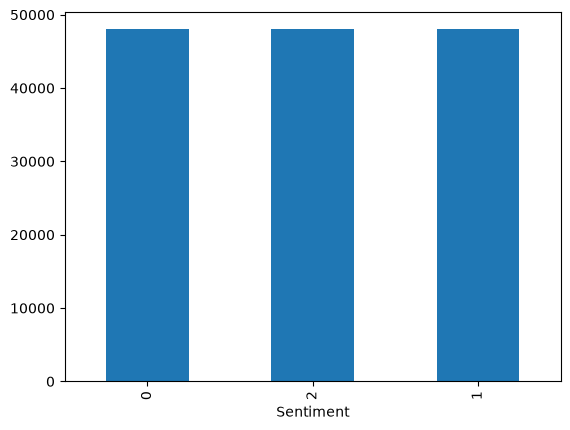

In [16]:
df['Sentiment'].value_counts().plot(kind='bar')

plt.show()

In [17]:
print(df.columns)

Index(['Comment', 'Sentiment'], dtype='str')


In [18]:
# convert text to lowercase 
df["Comment"] = df["Comment"].astype(str).str.lower()

In [19]:
# remove functuation
import string

df["Comment"] = df["Comment"].apply(
    lambda x: x.translate(str.maketrans("", "", string.punctuation))
)

Remove numbers

In [20]:
import re

df["Comment"] = df["Comment"].apply(
    lambda x: re.sub(r"\d+", "", x)
)

remove extra spaces

In [21]:
df["Comment"] = df["Comment"].apply(
    lambda x: re.sub(r"\s+", " ", x).strip()
)

remove stopwords

In [22]:
import nltk
nltk.download("stopwords")

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

df["Comment"] = df["Comment"].apply(
    lambda x: " ".join(
        word for word in x.split()
        if word not in stop_words
    )
)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Feature Extraction

In [23]:
x = df['Comment']
y = df['Sentiment']

In [24]:

tfidf = TfidfVectorizer(max_features=5000, min_df=3, max_df=0.9, dtype=np.float32)


Split Data (apply vectorizer)

In [25]:
# Split RAW text first
x_train_text, x_test_text, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

# Fit TF-IDF only on train
tfidf = TfidfVectorizer(max_features=5000, min_df=3, max_df=0.9, dtype=np.float32)
x_train = tfidf.fit_transform(x_train_text)     # fit + transform on train
x_test = tfidf.transform(x_test_text)           # transform only on test

Handle imbalance data

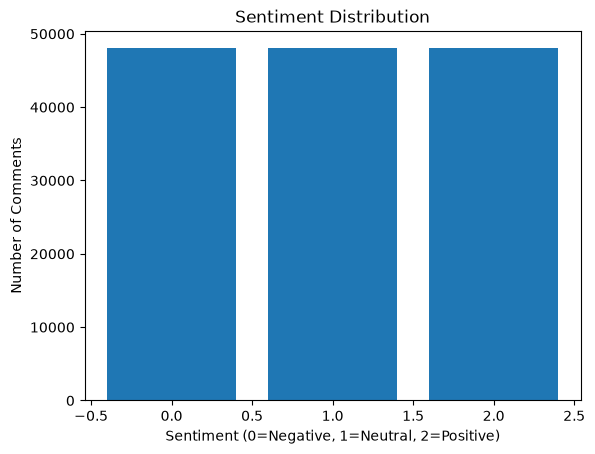

In [27]:
import matplotlib.pyplot as plt

sentiment_counts = df['Sentiment'].value_counts().sort_index()

plt.figure()
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.xlabel("Sentiment (0=Negative, 1=Neutral, 2=Positive)")
plt.ylabel("Number of Comments")
plt.title("Sentiment Distribution")
plt.show()


Keep data sparse (avoid densifying the full matrix — it's too large for memory)

In [28]:
print('x_train_s shape (sparse):', x_train.shape)
print('x_test shape (sparse):    ', x_test.shape)


x_train_s shape (sparse): (115200, 5000)
x_test shape (sparse):     (28800, 5000)


Labels as arrays (features stay sparse, converted per-batch later)

In [ ]:
x_train_arr, x_test_arr = x_train, x_test   
y_train_arr = y_train.to_numpy()
y_test_arr = y_test.to_numpy()

In [30]:
print('Train samples:', x_train.shape[0], '| Features:', x_train.shape[1])


Train samples: 115200 | Features: 5000


In [31]:
print('Test samples:', x_test.shape[0], '| Features:', x_test.shape[1])


Test samples: 28800 | Features: 5000


In [32]:
print(y_train_arr[:20])


[0 0 1 2 0 0 1 1 1 0 2 2 1 1 2 1 2 1 1 2]


In [33]:
print(y_test_arr[:20])


[2 1 0 2 0 1 1 0 1 2 0 0 0 2 2 1 1 2 2 0]


Create Dataset (sparse-aware — densifies only one batch at a time)

In [34]:
from torch.utils.data import Dataset, DataLoader, BatchSampler, RandomSampler, SequentialSampler

class SparseDataset(Dataset):
   

    def __init__(self, X_sparse, y):
        self.X = X_sparse.tocsr()
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):

        X_batch = self.X[idx].toarray()
        y_batch = self.y[idx]
        return torch.from_numpy(X_batch).float(), torch.from_numpy(y_batch).long()


train_dataset = SparseDataset(x_train, y_train_arr)
test_dataset = SparseDataset(x_test, y_test_arr)


Create DataLoader (batch_size=None + BatchSampler → dataset receives a batch of indices, not one row at a time — much faster with sparse data)

In [35]:
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    sampler=BatchSampler(RandomSampler(train_dataset), batch_size=batch_size, drop_last=False),
    batch_size=None
)

test_loader = DataLoader(
    test_dataset,
    sampler=BatchSampler(SequentialSampler(test_dataset), batch_size=batch_size, drop_last=False),
    batch_size=None
)


Build Model

In [36]:
class SentimentANN(nn.Module):
    def __init__(self, input_size, num_classes=3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.6),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(32, num_classes)
        )
    def forward(self, x):
        return self.network(x)
    
input_size = x_train.shape[1]
model = SentimentANN(input_size)

In [37]:
print(model)

SentimentANN(
  (network): Sequential(
    (0): Linear(in_features=5000, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.6, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=32, out_features=3, bias=True)
  )
)


In [45]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)  # was 1e-4

Training

In [ ]:
epochs = 60

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)

    # validation using your test_loader
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            val_loss += criterion(model(xb), yb).item() * xb.size(0)
    val_loss /= len(test_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

Epoch 1 - Train Loss: 0.6126 - Val Loss: 0.5292
Epoch 2 - Train Loss: 0.5932 - Val Loss: 0.5266
Epoch 3 - Train Loss: 0.5809 - Val Loss: 0.5259
Epoch 4 - Train Loss: 0.5818 - Val Loss: 0.5271
Epoch 5 - Train Loss: 0.5782 - Val Loss: 0.5232
Epoch 6 - Train Loss: 0.5732 - Val Loss: 0.5225
Epoch 7 - Train Loss: 0.5736 - Val Loss: 0.5266
Epoch 8 - Train Loss: 0.5756 - Val Loss: 0.5247
Epoch 9 - Train Loss: 0.5753 - Val Loss: 0.5254
Epoch 10 - Train Loss: 0.5775 - Val Loss: 0.5235
Epoch 11 - Train Loss: 0.5755 - Val Loss: 0.5244
Epoch 12 - Train Loss: 0.5727 - Val Loss: 0.5244
Epoch 13 - Train Loss: 0.5727 - Val Loss: 0.5224
Epoch 14 - Train Loss: 0.5751 - Val Loss: 0.5247
Epoch 15 - Train Loss: 0.5733 - Val Loss: 0.5247
Epoch 16 - Train Loss: 0.5742 - Val Loss: 0.5269
Epoch 17 - Train Loss: 0.5745 - Val Loss: 0.5246
Epoch 18 - Train Loss: 0.5739 - Val Loss: 0.5234
Epoch 19 - Train Loss: 0.5756 - Val Loss: 0.5230
Epoch 20 - Train Loss: 0.5734 - Val Loss: 0.5227
Epoch 21 - Train Loss: 0.5735

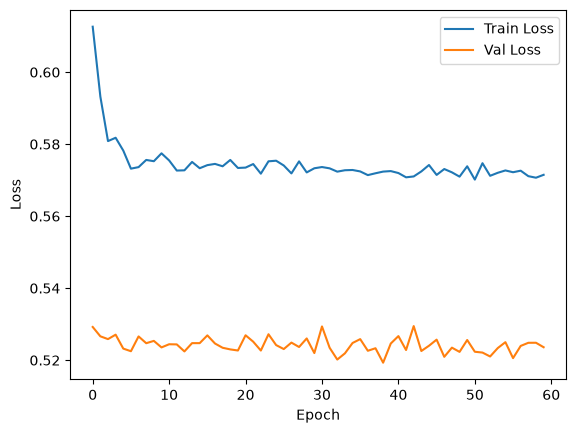

In [47]:
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Evaluation metrics

In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:

        outputs = model(xb)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.numpy())
        all_labels.extend(yb.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Calculate metrics
acc = accuracy_score(all_labels, all_preds)

prec = precision_score(
    all_labels,
    all_preds,
    average="macro",
    zero_division=0
)

rec = recall_score(
    all_labels,
    all_preds,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_preds,
    average="macro",
    zero_division=0
)

print(f"Accuracy:  {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Recall:    {rec*100:.2f}%")
print(f"F1-score:  {f1*100:.2f}%")


Accuracy:  81.10%
Precision: 81.43%
Recall:    81.10%
F1-score:  81.09%


In [ ]:
def evaluate_accuracy(loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in loader:
            outputs = model(xb)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == yb).sum().item()
            total += yb.size(0)

    return (correct / total) * 100


# Calculate accuracy
train_acc = evaluate_accuracy(train_loader)
test_acc = evaluate_accuracy(test_loader)

print(f"Training Accuracy: {train_acc:.2f}%")
print(f"Testing Accuracy:  {test_acc:.2f}%")

# Check overfitting
if train_acc - test_acc > 10:
    print("\nNote: Training accuracy is much higher than testing accuracy — possible overfitting.")
else:
    print("\nTrain and test accuracy are close — no strong sign of overfitting.")


Test With Your Own Input



In [ ]:
label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}

def preprocess_text(text):
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = " ".join(word for word in text.split() if word not in stop_words)
    return text

def predict_sentiment(text):
    cleaned = preprocess_text(text)
    vec = tfidf.transform([cleaned]).toarray()
    vec_t = torch.from_numpy(vec).float()

    model.eval()
    with torch.no_grad():
        output = model(vec_t)
        probs = torch.softmax(output, dim=1).numpy()[0]
        _, predicted = torch.max(output, 1)

    pred_label = label_map[predicted.item()]

    print(f"Input:     {text}")
    print(f"Predicted: {pred_label}")
    
    return pred_label


sample_text = "opinion hell thank whole country giving opportunity serve nation,"
predict_sentiment(sample_text)


Input:     opinion hell thank whole country giving opportunity serve nation,
Predicted: Positive


'Positive'

Save the trained model

In [44]:
import json
import joblib

# 1. Model weights
torch.save(model.state_dict(), "best_model.pth")

# 2. TF-IDF vectorizer (holds the vocabulary — needed to featurize new text later)
joblib.dump(tfidf, "tfidf_vectorizer.joblib")

# 3. Stopwords used during cleaning
joblib.dump(stop_words, "stop_words.joblib")

# 4. Small config: input size + label mapping
config = {
    "input_size": input_size,
    "num_classes": 3,
    "label_map": {"0": "Negative", "1": "Neutral", "2": "Positive"}
}
with open("model_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved: best_model.pth, tfidf_vectorizer.joblib, stop_words.joblib, model_config.json")

Saved: best_model.pth, tfidf_vectorizer.joblib, stop_words.joblib, model_config.json
